In [1]:
from langgraph.graph import StateGraph , START , END

from typing import TypedDict , Literal


In [3]:
class QuadState(TypedDict):
    a : int
    b : int 
    c : int
    
    equation : str
    discriminant : float
    result : str
    

In [9]:
def show_equation(state: QuadState):
    equation = f'{state["a"]}x**2 + {state["b"]}x + {state["c"]}'
    
    
    return {'equation' : equation}



In [21]:
def calculate_discriminant(state: QuadState):
    discriminant = state["b"]  **2 - (4* state["a"]*state["c"])
    
    return {"discriminant" : discriminant}



In [26]:
def real_roots(state: QuadState):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    
    result = f'The roots are {root1} and {root2}'
    
    return {'result' : result}


In [27]:
def repeated_roots(state: QuadState):
    root = (-state["b"]) /(2*state["a"])
   
    
    result = f'The roots are {root}'
    
    
    return {'result' : result}


In [29]:
def no_roots(state: QuadState):
        
    result = f'No real roots'
    
    
    return {'result' : result}


In [30]:
def check_condition(state: QuadState) -> Literal["real_roots" , "repeated_roots" , "no_roots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    
    elif state["discriminant"] == 0:
        return "repeated_roots"
    
    else:
        return "no_roots"
    
    

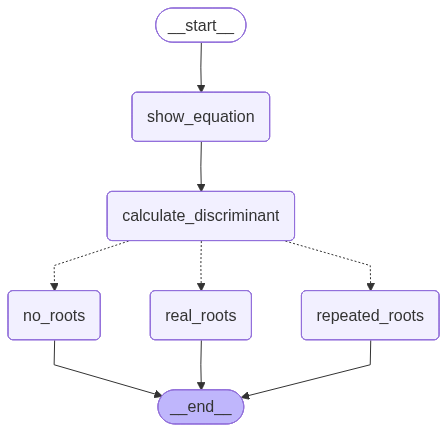

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation' , show_equation)
graph.add_node('calculate_discriminant' , calculate_discriminant)
graph.add_node('real_roots' , real_roots)
graph.add_node('no_roots' , no_roots)
graph.add_node('repeated_roots' , repeated_roots)



graph.add_edge(START , 'show_equation')
graph.add_edge('show_equation' , 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant' , check_condition)

graph.add_edge('real_roots' , END)
graph.add_edge('repeated_roots' , END)
graph.add_edge('no_roots' , END)



workflow = graph.compile()




In [35]:
initial_state = {
    'a' : 10,
    'b' : 10,
    'c' : 10
    }

workflow.invoke(initial_state)

{'a': 10,
 'b': 10,
 'c': 10,
 'equation': '10x**2 + 10x + 10',
 'discriminant': -300,
 'result': 'No real roots'}